# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from cross_sections_stats import *
%matplotlib inline
pd.set_option('display.max_rows', None)

### Provide Directories

#### Provide the directory for transmission images

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\03_ Stats\01_transmission_1h"

#### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [3]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\00_Raw_sorted\exp102\005_temp_01_p10_batch01\exp102_031_Spectra.txt"

#### Provide the directory for saving results

In [4]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\03_ Stats\02_rel_att_3h"

In [5]:
flight_path = 5.45

## Remove Casing 
read the directory and extract values from images

In [6]:
stack_dict = read_saved_dict (src_dir, proc_folder = ['f0'])

Reading Images: 100%|████████████████████████████| 1/1 [00:03<00:00,  3.76s/it]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [7]:
avg_imgs = []
for key, value in stack_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_slice = 40, end_slice = 50)
    avg_imgs.append(img[0])

#### Select the Casing ROI
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [8]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
#ROIs_003_temp_00_p20_batch03  = [[58, 296, 234, 54]]
ROIs_f0  = [[139, 20, 248, 194]]

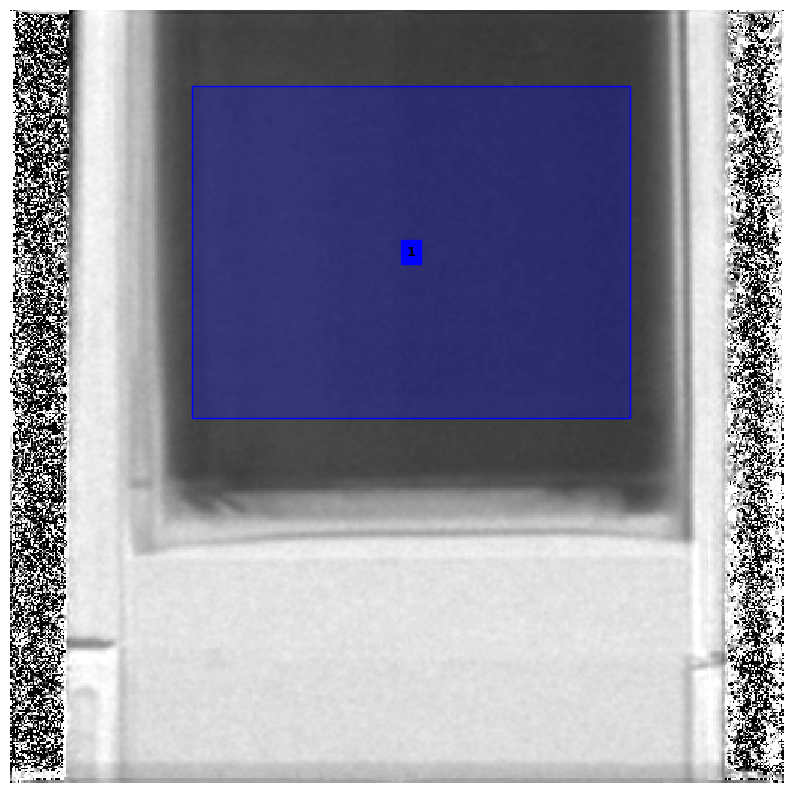

In [9]:
show_img(avg_imgs[0], dr = [(ROIs_f0, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [10]:
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the values

In [11]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [12]:
#val_rois = table_val_rois.loc[3:76, :]
#val_rois = table_val_rois.reset_index(drop=True)

val_rois

,Wavelength [Å],Values_acq_0,Values_acq_1,Values_acq_2,Values_acq_3,Values_acq_4,Values_acq_5,Values_acq_6,Values_acq_7,Values_acq_8,Values_acq_9
0,0.072588,0.541588,0.542937,0.550683,0.554923,0.553705,0.541609,0.548863,0.539281,0.556120,0.549182
1,0.130658,0.556583,0.548769,0.542967,0.552983,0.545747,0.545862,0.553406,0.546700,0.559056,0.556320
2,0.188728,0.544257,0.543403,0.551603,0.540459,0.552393,0.553413,0.555427,0.553102,0.555263,0.547325
3,0.246798,0.553085,0.549022,0.538042,0.543663,0.541264,0.548735,0.548214,0.542278,0.549366,0.539391
4,0.304869,0.552498,0.537205,0.547124,0.549205,0.556795,0.541230,0.543362,0.547632,0.549275,0.549141
5,0.362939,0.543146,0.545396,0.544086,0.540845,0.542439,0.544766,0.545888,0.545886,0.549508,0.547506
6,0.421009,0.540386,0.536399,0.545079,0.536157,0.527975,0.538279,0.539735,0.547274,0.531256,0.534979
7,0.479079,0.531390,0.532806,0.540944,0.532169,0.536171,0.533010,0.541512,0.535397,0.538322,0.538102
8,0.537150,0.526064,0.539547,0.534041,0.538402,0.530517,0.522485,0.538857,0.528814,0.539154,0.533798
9,0.595220,0.531833,0.535020,0.525463,0.541680,0.524121,0.528365,0.532416,0.535381,0.533388,0.533857


### H cross section parameters

In [13]:
thickness = 0.3
h2o = {'abbv': 'H2O','composition' : {'H':2.0, 'O':1.0},'density':0.997, 'thickness': thickness}
ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.28, 'thickness': thickness}
ec_dmc_11w = {'abbv': 'EC_DMC (1:1w)','molecules' : [ec,0.447511501,dmc,0.552488499], 'density':1.2335, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
#ec_dec_37w = {'abbv': 'EC_DEC (3:7w)','molecules' : [ec,0.240305619,dec,0.759694381], 'density':1.0705, 'thickness': thickness}
lp30 = {'abbv': 'LP30','molecules' : [ec, 0.406359477,dmc, 0.501683056, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}
lp47 = {'abbv': 'LP47','molecules' : [ec, 0.218207723,dec, 0.689834809, lipf6 ,0.091957467], 'density':1.1685, 'thickness': thickness}
#ec_dec_sol = {'abbv': 'EC_DEC (sol)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
pe = {'abbv': 'PE', 'composition' : {'C':1.0, 'H':2.0},'density':0.92, 'thickness': 0.22}

## exp1000 -> LP30


In [14]:
compounds_dict = [pe, pe, pe, pe, pe, pe, pe , pe , pe , pe]

### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

In [15]:
requested_cs = ['total_cs']
cs_table = get_cross_sections (val_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')

In [16]:
cs_table

,Wavelength [Å],CS_tot_PE_Values_acq_0,CS_tot_PE_Values_acq_1,CS_tot_PE_Values_acq_2,CS_tot_PE_Values_acq_3,CS_tot_PE_Values_acq_4,CS_tot_PE_Values_acq_5,CS_tot_PE_Values_acq_6,CS_tot_PE_Values_acq_7,CS_tot_PE_Values_acq_8,CS_tot_PE_Values_acq_9
0,0.072588,70.571661,70.285546,68.655358,67.772591,68.025529,70.567281,69.036263,71.063061,67.524590,68.969347
1,0.130658,67.428918,69.055984,70.279184,68.175548,69.691409,69.667182,68.087553,69.490582,66.918614,67.483192
2,0.188728,70.005938,70.186704,68.463247,70.811862,68.298365,68.086233,67.668196,68.150809,67.702189,69.359149
3,0.246798,68.154334,69.002873,71.327633,70.131665,70.640621,69.063001,69.172466,70.425293,68.930896,71.039459
4,0.304869,68.276524,71.506767,69.401480,68.964434,67.384952,70.647798,70.195517,69.294593,68.949907,68.978048
5,0.362939,70.241090,69.765481,70.042130,70.729684,70.391027,69.898369,69.661567,69.662003,68.901069,69.321065
6,0.421009,70.827523,71.679706,69.832328,71.731509,73.501150,71.277000,70.966126,69.369819,72.788382,71.984582
7,0.479079,72.759308,72.452983,70.708622,72.590641,71.728641,72.409037,70.587803,71.894736,71.267757,71.314947
8,0.537150,73.918450,71.006226,72.186700,71.250781,72.948475,74.704073,71.153574,73.318465,71.090183,72.238953
9,0.595220,72.663427,71.975829,74.050005,70.552288,74.344395,73.416174,72.537264,71.898182,72.327463,72.226335


In [17]:
cs_ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI"
cs_ref_data = pd.read_csv (cs_ref_dir + '\cs_ref_IMAT20.txt',sep='\t')
cs_ref_data = cs_ref_data.loc[0:93, ['orig wvl','orig cs LP30', 'orig cs PE']]
cs_ref_data = cs_ref_data.reset_index(drop=True)
cs_ref_data

,orig wvl,orig cs LP30,orig cs PE
0,0.764306,33.804776,31.284488
1,0.822177,35.737919,33.045642
2,0.880048,37.725214,35.043827
3,0.937919,39.953408,36.966376
4,0.995790,42.166055,39.037189
5,1.053661,44.077816,41.065673
6,1.111533,45.960390,43.014795
7,1.169404,47.779011,44.856225
8,1.227275,49.188956,46.486678
9,1.285146,50.801343,48.109889


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


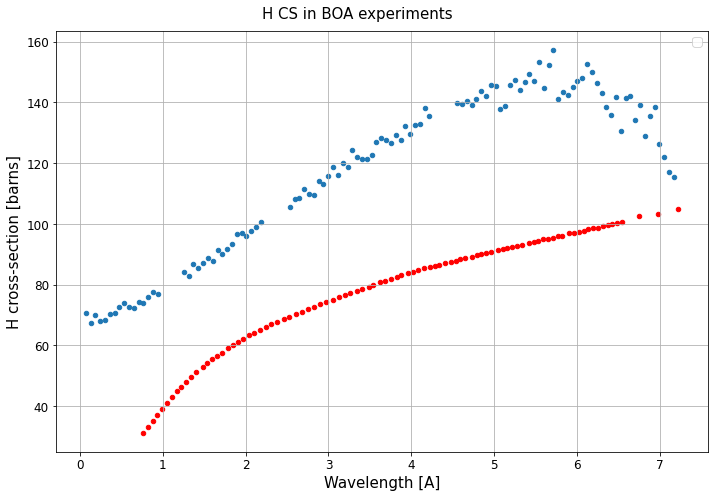

In [18]:
plt.rcParams["figure.figsize"] = [10.0, 7.0]
plt.rcParams["figure.autolayout"] = True

ax = cs_table.plot.scatter(x='Wavelength [Å]', y=['CS_tot_PE_Values_acq_0'])
cs_ref_data.plot(ax = ax, x='orig wvl', y=['orig cs PE'], 
                 grid = True, fontsize = 12, kind = 'scatter', color = 'r')

plt.suptitle('H CS in BOA experiments', fontsize=15)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("H cross-section [barns]")
ax.legend(fontsize=12)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
plt.show()

## for all the exps


In [25]:
exp = 'f1'
ROIs_f1  = [[139, 20, 248, 194]]
stack_dict = read_saved_dict (src_dir, proc_folder = [exp])
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\03_ Stats\01_transmission_1h"
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

Reading Images: 100%|████████████████████████████| 1/1 [00:05<00:00,  5.63s/it]


In [26]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

,Wavelength [Å],Values_acq_0,Values_acq_1,Values_acq_2,Values_acq_3,Values_acq_4,Values_acq_5,Values_acq_6,Values_acq_7,Values_acq_8,Values_acq_9
0,0.072588,0.549396,0.551868,0.551769,0.554346,0.552900,0.546219,0.546196,0.553238,0.542889,0.537171
1,0.130658,0.556098,0.543008,0.542919,0.556751,0.543248,0.550708,0.544647,0.552936,0.554748,0.544448
2,0.188728,0.542503,0.552118,0.542211,0.564244,0.563600,0.545312,0.548813,0.552949,0.552342,0.546984
3,0.246798,0.540210,0.545741,0.543570,0.546925,0.559784,0.543069,0.550388,0.549020,0.539241,0.538486
4,0.304869,0.543352,0.549142,0.536567,0.554287,0.558120,0.546135,0.532645,0.539353,0.540747,0.533802
5,0.362939,0.546822,0.540942,0.530274,0.548441,0.545439,0.548140,0.539161,0.542191,0.536475,0.542863
6,0.421009,0.533935,0.535474,0.541607,0.534444,0.558746,0.545043,0.539577,0.541107,0.539330,0.537880
7,0.479079,0.541463,0.524365,0.531303,0.543478,0.543833,0.531547,0.532921,0.527820,0.536554,0.530430
8,0.537150,0.528830,0.527376,0.527176,0.542223,0.530081,0.530510,0.534002,0.533690,0.528894,0.522969
9,0.595220,0.522493,0.530234,0.525900,0.531716,0.526845,0.519547,0.528080,0.527544,0.533685,0.529805


In [27]:
requested_cs = ['total_cs']
cs_table = get_cross_sections (val_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')
cs_table

,Wavelength [Å],CS_tot_PE_Values_acq_0,CS_tot_PE_Values_acq_1,CS_tot_PE_Values_acq_2,CS_tot_PE_Values_acq_3,CS_tot_PE_Values_acq_4,CS_tot_PE_Values_acq_5,CS_tot_PE_Values_acq_6,CS_tot_PE_Values_acq_7,CS_tot_PE_Values_acq_8,CS_tot_PE_Values_acq_9
0,0.072588,68.924575,68.407940,68.428436,67.892397,68.192914,69.591855,69.596813,68.122530,70.295553,71.514173
1,0.130658,67.529228,70.270425,70.289312,67.394102,70.219570,68.650034,69.923632,68.185469,67.808905,69.965604
2,0.188728,70.377430,68.355827,70.439412,65.855680,65.987173,69.783158,69.046639,68.182762,68.309124,69.430846
3,0.246798,70.864814,69.692741,70.151452,69.443171,66.768890,70.257480,68.716903,69.003398,71.071572,71.232675
4,0.304869,70.197610,68.977825,71.643553,67.904577,67.111445,69.609569,72.487805,71.047665,70.750667,72.238082
5,0.362939,69.464950,70.708989,73.001218,69.124673,69.756404,69.187802,71.088497,70.443706,71.663308,70.301234
6,0.421009,72.209476,71.878297,70.567704,72.099880,66.982451,69.839905,70.999915,70.673990,71.052477,71.362274
7,0.479079,70.598395,74.290796,72.778099,70.170925,70.095668,72.725350,72.428244,73.535039,71.646280,72.967288
8,0.537150,73.315033,73.631796,73.675540,70.436970,73.043027,72.949964,72.194929,72.262199,73.301155,74.597607
9,0.595220,74.702250,73.009933,73.954344,72.688635,73.747814,75.353004,73.478367,73.595304,72.263368,73.103032


In [28]:
exp = 'f2'
ROIs_f2  = [[139, 20, 248, 194]]
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\03_ Stats\01_transmission_1h"
stack_dict = read_saved_dict (src_dir, proc_folder = [exp])
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

Reading Images: 100%|████████████████████████████| 1/1 [00:03<00:00,  3.94s/it]


In [29]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [30]:
requested_cs = ['total_cs']
cs_table = get_cross_sections (val_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')
cs_table

,Wavelength [Å],CS_tot_PE_Values_acq_0,CS_tot_PE_Values_acq_1,CS_tot_PE_Values_acq_2,CS_tot_PE_Values_acq_3,CS_tot_PE_Values_acq_4,CS_tot_PE_Values_acq_5,CS_tot_PE_Values_acq_6,CS_tot_PE_Values_acq_7,CS_tot_PE_Values_acq_8,CS_tot_PE_Values_acq_9
0,0.072588,66.706946,70.817195,68.354022,70.229740,71.737419,68.799706,68.627117,70.271042,69.122355,71.883162
1,0.130658,67.487369,68.306711,69.034371,67.580926,67.102143,68.533070,68.394809,69.495852,70.847434,70.528260
2,0.188728,66.013088,70.318349,71.340279,69.611404,69.125640,68.662835,71.480690,71.180282,70.895246,69.161477
3,0.246798,67.480473,72.129579,70.931476,70.398192,70.068971,69.160597,72.000407,70.349041,69.774009,70.580024
4,0.304869,68.135719,70.065589,71.450636,70.766214,70.220122,72.129148,67.721898,69.933708,71.441050,71.357731
5,0.362939,68.960557,70.880177,70.007604,72.128531,71.782367,70.123191,72.727063,69.956492,68.975533,68.974474
6,0.421009,67.274732,72.001171,72.077215,73.449058,72.261140,71.811734,71.797491,71.899279,71.298484,71.975698
7,0.479079,71.957291,70.361460,72.823847,69.867664,75.124797,70.841179,71.938072,73.289259,71.869356,71.970939
8,0.537150,73.610648,73.810171,73.505894,73.947200,73.277176,72.919754,74.143081,72.550369,74.005749,72.312586
9,0.595220,72.202880,72.713670,73.922897,75.715813,75.457635,75.165398,74.939135,73.225882,72.920255,72.429581


In [103]:
exp = 'f3'
ROIs_f3  = [[120, 50, 290, 220]]
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\03_ Stats\01_transmission_1h"
stack_dict = read_saved_dict (src_dir, proc_folder = [exp])
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

Reading Images: 0it [00:00, ?it/s]


In [106]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [107]:
requested_cs = ['total_cs']
cs_table = get_cross_sections (val_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')
cs_table

,Wavelength [Å],CS_tot_PE_Values_acq_0,CS_tot_PE_Values_acq_1,CS_tot_PE_Values_acq_2,CS_tot_PE_Values_acq_3,CS_tot_PE_Values_acq_4,CS_tot_PE_Values_acq_5,CS_tot_PE_Values_acq_6,CS_tot_PE_Values_acq_7,CS_tot_PE_Values_acq_8,CS_tot_PE_Values_acq_9
0,0.072588,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
1,0.130658,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
2,0.188728,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
3,0.246798,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
4,0.304869,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
5,0.362939,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
6,0.421009,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
7,0.479079,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
8,0.537150,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf
9,0.595220,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf,-inf


In [54]:
exp = 'f4'
ROIs_f4  = [[120, 50, 290, 220]]
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\03_ Stats\00_transmission_3h"
stack_dict = read_saved_dict (src_dir, proc_folder = [exp])
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

Reading Images: 100%|████████████████████████████| 1/1 [00:04<00:00,  4.01s/it]


In [55]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [56]:
requested_cs = ['total_cs']
cs_table = get_cross_sections (val_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')
cs_table

,Wavelength [Å],CS_tot_PE_Values_acq_0,CS_tot_PE_Values_acq_1,CS_tot_PE_Values_acq_2,CS_tot_PE_Values_acq_3,CS_tot_PE_Values_acq_4,CS_tot_PE_Values_acq_5,CS_tot_PE_Values_acq_6,CS_tot_PE_Values_acq_7,CS_tot_PE_Values_acq_8,CS_tot_PE_Values_acq_9
0,0.072588,65.824585,69.417082,69.187423,69.847928,71.689791,69.606955,68.570562,69.297406,68.990978,70.838251
1,0.130658,71.672462,69.080632,65.270368,67.789246,69.155363,69.328956,70.374469,68.776566,67.363608,68.506821
2,0.188728,69.536466,69.579734,68.442028,69.157654,69.955509,70.665762,66.634603,70.282250,70.029636,67.660060
3,0.246798,70.359857,70.251010,68.368450,69.423566,68.709079,71.029198,67.666996,68.098475,69.415386,67.931189
4,0.304869,66.288156,71.033571,72.313779,70.493389,68.595563,68.930580,70.891703,69.644014,68.255304,71.486365
5,0.362939,68.590663,70.979469,69.609671,71.554763,70.491014,70.346390,71.895658,69.869567,72.078654,72.529309
6,0.421009,71.729468,71.450267,71.447887,70.557704,71.086464,71.338466,71.799370,70.319710,71.015211,72.870368
7,0.479079,70.235718,71.320645,71.937715,71.237284,72.517810,70.337937,71.706679,70.149165,72.691214,72.425628
8,0.537150,72.433443,72.002648,73.411808,71.870102,72.532334,71.995393,74.213800,71.832348,73.236216,73.414809
9,0.595220,73.384382,72.574971,74.287984,72.848235,71.497617,73.009217,74.990357,72.594696,73.996545,72.583681


In [57]:
exp = 'f5'
ROIs_f5  = [[120, 50, 290, 220]]
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\03_ Stats\00_transmission_3h"
stack_dict = read_saved_dict (src_dir, proc_folder = [exp])
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

Reading Images: 100%|████████████████████████████| 1/1 [00:03<00:00,  3.91s/it]


In [58]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [59]:
requested_cs = ['total_cs']
cs_table = get_cross_sections (val_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')
cs_table

,Wavelength [Å],CS_tot_PE_Values_acq_0,CS_tot_PE_Values_acq_1,CS_tot_PE_Values_acq_2,CS_tot_PE_Values_acq_3,CS_tot_PE_Values_acq_4,CS_tot_PE_Values_acq_5,CS_tot_PE_Values_acq_6,CS_tot_PE_Values_acq_7,CS_tot_PE_Values_acq_8,CS_tot_PE_Values_acq_9
0,0.072588,68.524992,69.057796,69.904739,67.886837,70.021099,67.809385,68.810368,70.000931,69.328663,69.764487
1,0.130658,68.014105,67.029570,68.440281,68.132803,69.054325,66.230308,65.931283,67.815996,68.510848,67.986439
2,0.188728,69.341844,68.776937,68.721074,69.386256,68.967526,65.910684,69.423027,68.047445,67.437834,69.611790
3,0.246798,70.132274,70.425684,69.915274,70.637001,70.048398,66.922102,70.066545,69.589104,67.949950,67.978858
4,0.304869,71.502334,68.500449,68.753166,70.211636,68.310375,71.861859,70.161705,70.691612,70.872705,67.655333
5,0.362939,69.691381,72.019951,70.560627,69.776703,71.817405,69.860463,69.525679,70.699279,71.210712,70.314944
6,0.421009,71.483779,71.382917,71.335677,72.404195,69.696897,69.777253,72.765095,71.501715,69.802988,70.833877
7,0.479079,73.031507,71.920191,71.888321,72.710302,71.638878,73.498132,71.997565,71.363690,72.925659,70.067714
8,0.537150,73.115661,71.723032,72.629603,73.141785,71.120061,74.260855,70.912458,71.799964,71.246863,73.662883
9,0.595220,72.939176,73.484911,72.379915,73.772010,73.142871,74.284505,72.843569,73.037770,71.455334,73.071904


In [60]:
exp = 'f6'
ROIs_f6  = [[120, 50, 290, 220]]
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\03_ Stats\00_transmission_3h"
stack_dict = read_saved_dict (src_dir, proc_folder = [exp])
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

Reading Images: 100%|████████████████████████████| 1/1 [00:04<00:00,  4.13s/it]


In [61]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [62]:
requested_cs = ['total_cs']
cs_table = get_cross_sections (val_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')
cs_table

,Wavelength [Å],CS_tot_PE_Values_acq_0,CS_tot_PE_Values_acq_1,CS_tot_PE_Values_acq_2,CS_tot_PE_Values_acq_3,CS_tot_PE_Values_acq_4,CS_tot_PE_Values_acq_5,CS_tot_PE_Values_acq_6,CS_tot_PE_Values_acq_7,CS_tot_PE_Values_acq_8,CS_tot_PE_Values_acq_9
0,0.072588,66.112133,70.366924,69.018732,70.078962,68.590964,69.657437,70.262881,68.380158,69.266658,67.793188
1,0.130658,69.348919,71.013887,69.239332,69.820392,68.076433,67.237893,68.536941,65.546060,68.678056,68.854929
2,0.188728,67.949103,66.327489,68.394408,68.262338,70.298683,68.550896,69.040006,68.056080,68.025775,69.159255
3,0.246798,69.186469,70.806381,67.442229,69.578935,67.769513,71.442443,69.428959,69.690717,70.723645,69.157701
4,0.304869,69.997575,67.722322,70.278200,70.357643,68.349262,69.709887,69.622347,70.901036,69.560943,69.316198
5,0.362939,68.631492,70.648603,70.928660,71.564835,70.643970,69.325571,72.438579,70.831538,71.034183,71.186040
6,0.421009,70.747917,68.499790,71.224167,70.271423,70.565283,71.213367,71.337910,70.767394,72.497575,71.222304
7,0.479079,70.963724,71.443848,73.049610,69.567877,71.604920,72.298774,72.196820,74.054399,70.992925,70.823813
8,0.537150,72.629645,71.887200,74.689620,70.932048,72.501927,73.082813,72.736876,71.796775,70.662644,71.519417
9,0.595220,74.226907,70.938435,70.431045,71.794945,71.139853,73.732527,72.670521,72.188639,72.500440,72.460425


In [63]:
exp = 'f7'
ROIs_f7  = [[120, 50, 290, 220]]
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\03_ Stats\00_transmission_3h"
stack_dict = read_saved_dict (src_dir, proc_folder = [exp])
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

Reading Images: 100%|████████████████████████████| 1/1 [00:04<00:00,  4.13s/it]


In [64]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [65]:
requested_cs = ['total_cs']
cs_table = get_cross_sections (val_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')
cs_table

,Wavelength [Å],CS_tot_PE_Values_acq_0,CS_tot_PE_Values_acq_1,CS_tot_PE_Values_acq_2,CS_tot_PE_Values_acq_3,CS_tot_PE_Values_acq_4,CS_tot_PE_Values_acq_5,CS_tot_PE_Values_acq_6,CS_tot_PE_Values_acq_7,CS_tot_PE_Values_acq_8,CS_tot_PE_Values_acq_9
0,0.072588,69.240529,69.609605,69.492742,69.924995,68.110519,67.733172,69.556093,66.984633,70.345168,69.991076
1,0.130658,67.529982,69.039087,70.280969,68.112464,68.890805,70.299214,68.776376,71.106978,68.120508,69.365497
2,0.188728,66.841767,67.800237,68.323485,66.491423,67.635745,66.082186,68.160391,69.560773,69.368908,69.472299
3,0.246798,69.291046,69.026120,69.150190,68.839429,71.044130,68.469300,69.051348,70.045810,69.178269,70.901666
4,0.304869,69.804732,70.174635,70.364224,69.039703,68.043521,71.050203,69.144011,70.942517,70.354942,70.448774
5,0.362939,69.107070,70.317599,71.673710,69.801526,69.148089,69.630007,70.366221,70.985859,70.139870,69.581326
6,0.421009,71.331673,72.916886,70.888881,70.462189,72.691391,71.537922,70.739115,71.417176,70.083784,72.648864
7,0.479079,70.498595,71.389076,70.281862,70.354671,72.271943,74.155713,73.223216,72.435057,72.074609,70.232181
8,0.537150,72.978580,72.606355,70.783230,71.595506,71.621910,72.880178,70.573655,71.868834,71.898117,70.594099
9,0.595220,72.820303,71.462439,73.405195,72.228814,73.113807,72.770354,71.661112,73.501896,71.249257,72.203798


In [66]:
exp = 'f8'
ROIs_f8  = [[120, 50, 290, 220]]
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\03_ Stats\00_transmission_3h"
stack_dict = read_saved_dict (src_dir, proc_folder = [exp])
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

Reading Images: 100%|████████████████████████████| 1/1 [00:03<00:00,  3.62s/it]


In [67]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [68]:
requested_cs = ['total_cs']
cs_table = get_cross_sections (val_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')
cs_table

,Wavelength [Å],CS_tot_PE_Values_acq_0,CS_tot_PE_Values_acq_1,CS_tot_PE_Values_acq_2,CS_tot_PE_Values_acq_3,CS_tot_PE_Values_acq_4,CS_tot_PE_Values_acq_5,CS_tot_PE_Values_acq_6,CS_tot_PE_Values_acq_7,CS_tot_PE_Values_acq_8
0,0.072588,70.296479,69.718481,70.829481,69.816104,68.601408,69.691046,68.122257,66.807804,68.237548
1,0.130658,69.892864,67.511409,70.245591,70.472166,68.419868,69.024251,67.980936,68.824146,67.739025
2,0.188728,68.961642,68.016267,70.732238,70.347693,68.971744,66.232141,67.498199,67.763136,68.556505
3,0.246798,67.384774,69.536430,69.646402,67.933832,70.700630,70.345349,67.514577,69.592545,70.431833
4,0.304869,70.429191,69.397438,68.860490,70.236044,68.642109,67.583566,70.407137,70.926779,70.870370
5,0.362939,69.583648,70.536044,71.477217,68.935162,71.103706,70.414570,69.626669,72.757548,73.624266
6,0.421009,71.619288,70.280993,71.544606,72.334018,71.334553,68.521938,71.412244,72.487229,71.126511
7,0.479079,70.149408,71.959192,71.710785,71.883046,72.765978,71.234200,71.083029,71.522291,71.968859
8,0.537150,72.096212,71.972697,71.570547,72.148480,71.507086,72.059380,69.822299,73.254067,72.768209
9,0.595220,73.476778,71.625939,71.777941,71.532516,70.649358,73.687331,72.794472,73.392208,73.360385
